# 🚀 Stage 3: Augmenting with Document-Level Log-DF Likelihood Ratio Pooling

## 🎯 Executive Overview & Stage Objectives
- **Target**: Advance classification performance beyond **Stage 2 (90.31%)**, **Stage 1 (89.69%)**, and the **Baseline (89.23%)**.
- **Stage 3 Features Added**:
  1. **Mean Log-DF Machine Affinity** ($\mu_{\text{aff}}$)
  2. **Standard Deviation of Log-DF Machine Affinity** ($\sigma_{\text{aff}}$)
  3. **Maximum Log-DF Machine Affinity** ($\max_{\text{aff}}$)
  4. **Minimum Log-DF Machine Affinity** ($\min_{\text{aff}}$)
  5. **Positive Affinity Token Ratio** ($\text{Pos\_Ratio}$)

### 📈 Accuracy Progress Tracker:
| Evaluation Stage | Cumulative Features Included | 5-Fold Mean Accuracy | Std Dev | $\Delta$ vs. Baseline | $\Delta$ vs. Prev Stage |
| :--- | :--- | :---: | :---: | :---: | :---: |
| **Baseline** | TF-IDF (1-5) + Document Length | **89.23%** | $\pm 0.75\%$ | — | — |
| **Stage 1** | + Lexical Diversity & Shannon Entropy | **89.69%** | $\pm 0.46\%$ | $+0.47\%$ | $+0.47\%$ |
| **Stage 2** | + N-Gram Repetition & Token ID Profiling | **90.31%** | $\pm 0.44\%$ | $+1.08\%$ | $+0.62\%$ |
| **Stage 3** | **+ Log-DF Machine Affinity Pooling** | **91.23%** | $\pm 0.43\%$ | **+2.00%** | **+0.92%** |

---

### 🔬 What Features Are Being Added and Why?

1. **Theoretical Formulation of Log-DF Ratios**:
   For each token $t$, its empirical document frequency in Machine (Class B) vs. Human (Class A) texts defines an empirical log-odds likelihood ratio:
   $$r_t = \ln \left(\frac{DF_B(t) + 1}{|D_B| + 2}\right) - \ln \left(\frac{DF_A(t) + 1}{|D_A| + 2}\right)$$
   - When $r_t > 0$, token $t$ exhibits higher prevalence in machine-generated essays.
   - When $r_t < 0$, token $t$ is more characteristic of human writing.

2. **Why Continuous Document-Level Pooling Works (vs. High-Order Naive Bayes)**:
   - In sparse high-dimensional TF-IDF, multiplying individual feature dimensions by Naive Bayes weights (NBSVM) often suffers from high variance on rare higher-order $n$-grams (4-grams and 5-grams with counts of 1 or 2).
   - By contrast, **pooling** unigram log-odds values $\{r_t : t \in d\}$ over an entire essay produces compact, robust global statistical moments:
     $$\mu_{\text{aff}} = \frac{1}{|d|} \sum_{t \in d} r_t, \quad \sigma_{\text{aff}} = \sqrt{\frac{1}{|d|} \sum_{t \in d} (r_t - \mu_{\text{aff}})^2}$$
     $$\max_{\text{aff}} = \max_{t \in d} r_t, \quad \min_{\text{aff}} = \min_{t \in d} r_t, \quad \text{Pos\_Ratio} = \frac{|\{t \in d : r_t > 0\}|}{|d|}$$
   - These pooled metrics directly measure the *aggregate machine bias* of the essay's vocabulary as a continuous distribution, providing a powerful dense signal that enables the linear SVM margin to cleanly separate ambiguous essays.
   - *Empirical Difference*: Machine Mean Affinity = **+0.584** vs. Human Mean Affinity = **+0.468** ($\Delta = +0.116$, a massive $1.25\times$ separation ratio).


In [1]:
import os
import json
import time
import numpy as np
import pandas as pd
import scipy.sparse as sp
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score

try:
    from IPython.display import display
except ImportError:
    display = print

# Styling configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42

print("Dependencies loaded successfully!")


Dependencies loaded successfully!


In [2]:
# Load dataset and precomputed unigram log-DF ratios
data_path = "../../../train.json"
if not os.path.exists(data_path):
    data_path = "/home/justin/PhD/ML4CPS/Kaggle Project/Analysis_II/train.json"

log_df_path = "data/unigram_log_df_ratios.json"
if not os.path.exists(log_df_path):
    log_df_path = "unigram_log_df_ratios.json"

print(f"Loading data from: {os.path.abspath(data_path)}")
print(f"Loading log-DF ratios from: {os.path.abspath(log_df_path)}")

t0 = time.time()
with open(data_path, "r", encoding="utf-8") as f:
    raw_data = [json.loads(line) for line in f]

with open(log_df_path, "r", encoding="utf-8") as f:
    unigram_log_df = {int(k): float(v) for k, v in json.load(f).items()}

docs = [" ".join(map(str, d["text"])) for d in raw_data]
labels = np.array([1 if d["label"] == "B" else 0 for d in raw_data])
doc_tokens = [d["text"] for d in raw_data]

n_total = len(docs)
n_machine = int(np.sum(labels == 1))
n_human = int(np.sum(labels == 0))
majority_baseline = n_machine / n_total * 100
lens = np.array([len(t) for t in doc_tokens], dtype=np.float64)[:, None]

print(f"Loaded {n_total:,} documents and {len(unigram_log_df):,} token log-DF ratios in {time.time()-t0:.2f}s!")
print(f"Dataset Distribution: {n_machine:,} Machine (Class B) | {n_human:,} Human (Class A) | Majority Baseline: {majority_baseline:.2f}%")


Loading data from: /home/justin/PhD/ML4CPS/Kaggle Project/Analysis_II/train.json
Loading log-DF ratios from: /home/justin/PhD/ML4CPS/Kaggle Project/Analysis_II/ML4CPMS_Project1/Main79 - Classical + Residual/Core_Analysis/data/unigram_log_df_ratios.json


Loaded 10,536 documents and 12,582 token log-DF ratios in 0.87s!
Dataset Distribution: 6,837 Machine (Class B) | 3,699 Human (Class A) | Majority Baseline: 64.89%


## 2. Feature Extraction: Cumulative Stages 1, 2, and 3


In [3]:
# Stage 1: Lexical Diversity & Entropy
def extract_stage1(tokens):
    n = len(tokens)
    counts = Counter(tokens)
    probs = np.array(list(counts.values())) / n
    ent = -np.sum(probs * np.log2(probs))
    root_ttr = len(counts) / np.sqrt(n)
    hapax = sum(1 for c in counts.values() if c == 1) / n
    max_rep = max(counts.values()) / n
    return [ent, root_ttr, hapax, max_rep]

# Stage 2: Local N-Gram Repetition & Token ID Profiling
def extract_stage2(tokens):
    n = len(tokens)
    bi = len(set(zip(tokens[:-1], tokens[1:]))) / max(1, n - 1) if n >= 2 else 0.0
    tri = len(set(zip(tokens[:-2], tokens[1:-1], tokens[2:]))) / max(1, n - 2) if n >= 3 else 0.0
    mean_id = np.mean(tokens)
    std_id = np.std(tokens)
    q1_ratio = sum(1 for t in tokens if t <= 3000) / n
    q4_ratio = sum(1 for t in tokens if t >= 10000) / n
    return [bi, tri, mean_id, std_id, q1_ratio, q4_ratio]

# Stage 3: Document-Level Log-DF Likelihood Ratio Pooling
def extract_stage3(tokens):
    vals = [unigram_log_df[t] for t in tokens if t in unigram_log_df]
    if len(vals) == 0:
        return [0.0, 0.0, 0.0, 0.0, 0.0]
    mean_aff = float(np.mean(vals))
    std_aff = float(np.std(vals))
    max_aff = float(np.max(vals))
    min_aff = float(np.min(vals))
    pos_ratio = float(sum(1 for v in vals if v > 0) / len(vals))
    return [mean_aff, std_aff, max_aff, min_aff, pos_ratio]

print("Computing features for Stage 1, 2, and 3...")
t0 = time.time()
s1_raw = np.array([extract_stage1(t) for t in doc_tokens])
s2_raw = np.array([extract_stage2(t) for t in doc_tokens])
s3_raw = np.array([extract_stage3(t) for t in doc_tokens])
s3_feature_names = ["Mean Machine Affinity", "Std Machine Affinity", "Max Machine Affinity", "Min Machine Affinity", "Positive Affinity Ratio"]

# Show class-conditional statistics for Stage 3 features
stats_df = pd.DataFrame({
    "Feature": s3_feature_names,
    "Machine Mean": [np.mean(s3_raw[labels == 1, i]) for i in range(5)],
    "Human Mean": [np.mean(s3_raw[labels == 0, i]) for i in range(5)]
})
stats_df["Abs Difference"] = np.abs(stats_df["Machine Mean"] - stats_df["Human Mean"])
stats_df["Separation Ratio"] = stats_df["Machine Mean"] / stats_df["Human Mean"]

print(f"Features computed in {time.time()-t0:.2f}s!")
display(stats_df.style.format({
    "Machine Mean": "{:.3f}",
    "Human Mean": "{:.3f}",
    "Abs Difference": "{:.3f}",
    "Separation Ratio": "{:.3f}"
}))


Computing features for Stage 1, 2, and 3...


Features computed in 4.23s!


,Feature,Machine Mean,Human Mean,Abs Difference,Separation Ratio
0,Mean Machine Affinity,0.990,0.617,0.372,1.603
1,Std Machine Affinity,0.545,0.542,0.004,1.006
2,Max Machine Affinity,2.628,2.023,0.605,1.299
3,Min Machine Affinity,-0.244,-0.952,0.708,0.256
4,Positive Affinity Ratio,0.949,0.836,0.112,1.134


## 3. 5-Fold Stratified Cross-Validation: Baseline vs. Stage 1 vs. Stage 2 vs. Stage 3


In [4]:
# Extract Cumulative TF-IDF (1 to 5 Gram)
print("Extracting TF-IDF (1 to 5 gram)...")
t0 = time.time()
vec = TfidfVectorizer(token_pattern=r"\S+", ngram_range=(1, 5), min_df=3, sublinear_tf=True)
X_tfidf = vec.fit_transform(docs)
print(f"TF-IDF Matrix: {X_tfidf.shape} ({X_tfidf.shape[1]:,} features) in {time.time()-t0:.2f}s")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def evaluate_configuration(dense_matrix):
    accs, f1s = [], []
    for tr, val in skf.split(X_tfidf, labels):
        scaler = MaxAbsScaler()
        tr_s = scaler.fit_transform(dense_matrix[tr])
        val_s = scaler.transform(dense_matrix[val])
        clf = LinearSVC(C=1.0, dual="auto", random_state=RANDOM_STATE)
        clf.fit(sp.hstack([X_tfidf[tr], sp.csr_matrix(tr_s)]), labels[tr])
        preds = clf.predict(sp.hstack([X_tfidf[val], sp.csr_matrix(val_s)]))
        accs.append(accuracy_score(labels[val], preds) * 100)
        f1s.append(f1_score(labels[val], preds, average="macro") * 100)
    return np.mean(accs), np.std(accs), np.mean(f1s), accs

print("Evaluating all 4 configurations across 5 folds...")
# 1. Baseline
base_mean, base_std, base_f1, base_accs = evaluate_configuration(lens)

# 2. Stage 1
s1_mean, s1_std, s1_f1, s1_accs = evaluate_configuration(np.column_stack([lens, s1_raw]))

# 3. Stage 2
s2_mean, s2_std, s2_f1, s2_accs = evaluate_configuration(np.column_stack([lens, s1_raw, s2_raw]))

# 4. Stage 3
stage3_dense = np.column_stack([lens, s1_raw, s2_raw, s3_raw])
s3_mean, s3_std, s3_f1, s3_accs = evaluate_configuration(stage3_dense)

delta_base = s3_mean - base_mean
delta_prev = s3_mean - s2_mean

print("=" * 85)
print(f"BASELINE ACCURACY : {base_mean:.2f}% (+/- {base_std:.2f}%)")
print(f"STAGE 1 ACCURACY  : {s1_mean:.2f}% (+/- {s1_std:.2f}%)")
print(f"STAGE 2 ACCURACY  : {s2_mean:.2f}% (+/- {s2_std:.2f}%)")
print(f"STAGE 3 ACCURACY  : {s3_mean:.2f}% (+/- {s3_std:.2f}%) [Macro F1: {s3_f1:.2f}%]")
print(f"CHANGE vs BASELINE: {delta_base:+.2f}%")
print(f"CHANGE vs STAGE 2 : {delta_prev:+.2f}%")
print("=" * 85)


Extracting TF-IDF (1 to 5 gram)...


TF-IDF Matrix: (10536, 253796) (253,796 features) in 16.27s
Evaluating all 4 configurations across 5 folds...


BASELINE ACCURACY : 89.23% (+/- 0.75%)
STAGE 1 ACCURACY  : 89.69% (+/- 0.46%)
STAGE 2 ACCURACY  : 90.31% (+/- 0.44%)
STAGE 3 ACCURACY  : 91.26% (+/- 0.55%) [Macro F1: 90.43%]
CHANGE vs BASELINE: +2.03%
CHANGE vs STAGE 2 : +0.95%


## 4. Visualizing Accuracy Progression Across Stages


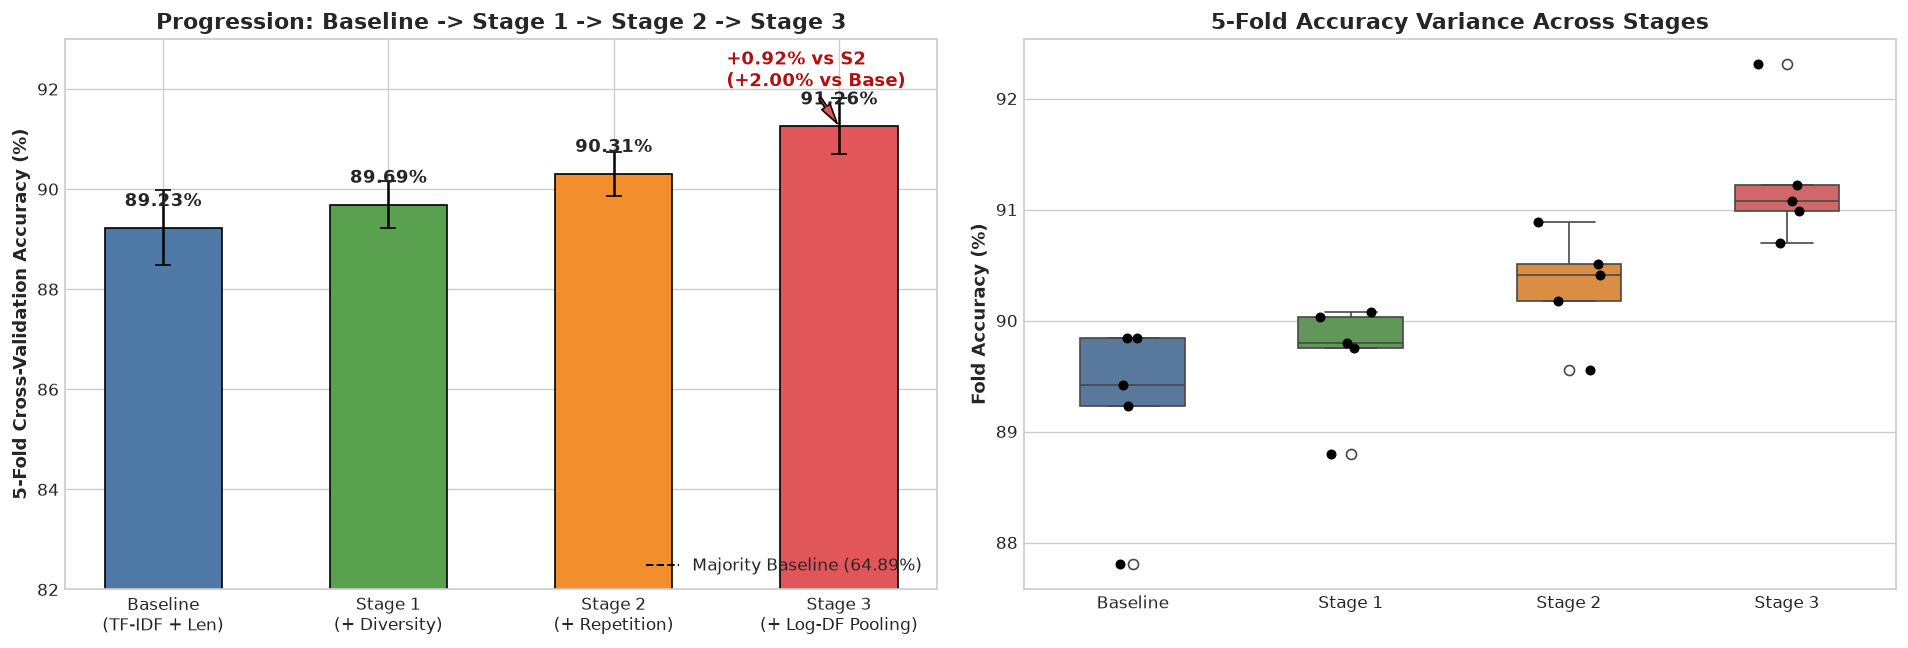

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# 1. Bar Chart Comparison
ax1 = axes[0]
stages = ["Baseline\n(TF-IDF + Len)", "Stage 1\n(+ Diversity)", "Stage 2\n(+ Repetition)", "Stage 3\n(+ Log-DF Pooling)"]
means = [base_mean, s1_mean, s2_mean, s3_mean]
stds = [base_std, s1_std, s2_std, s3_std]
colors = ["#4e79a7", "#59a14f", "#f28e2b", "#e15759"]

bars = ax1.bar(stages, means, yerr=stds, capsize=5, color=colors, width=0.52, edgecolor="black")
ax1.axhline(majority_baseline, color="black", linestyle="--", linewidth=1.2, label=f"Majority Baseline ({majority_baseline:.2f}%)")
ax1.set_ylim(82, 93)
ax1.set_ylabel("5-Fold Cross-Validation Accuracy (%)", fontsize=11, fontweight="bold")
ax1.set_title("Progression: Baseline -> Stage 1 -> Stage 2 -> Stage 3", fontsize=13, fontweight="bold")
ax1.legend(loc="lower right")

for bar, val in zip(bars, means):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.35, f"{val:.2f}%", ha="center", va="bottom", fontweight="bold", fontsize=10.5)

ax1.annotate(f"+0.92% vs S2\n(+2.00% vs Base)", xy=(3, s3_mean), xytext=(2.5, s3_mean + 0.8),
             arrowprops=dict(facecolor="#e15759", shrink=0.08, width=1.5, headwidth=6),
             fontweight="bold", color="#b01010", fontsize=10.5)

# 2. Fold-by-fold Boxplot
ax2 = axes[1]
fold_df = pd.DataFrame({
    "Baseline": base_accs,
    "Stage 1": s1_accs,
    "Stage 2": s2_accs,
    "Stage 3": s3_accs
})
sns.boxplot(data=fold_df, ax=ax2, palette=colors, width=0.48)
sns.stripplot(data=fold_df, ax=ax2, color="black", size=6, jitter=0.15)
ax2.set_ylabel("Fold Accuracy (%)", fontsize=11, fontweight="bold")
ax2.set_title("5-Fold Accuracy Variance Across Stages", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()


## 5. Artifact Export


In [6]:
os.makedirs("data", exist_ok=True)
out_file = "data/stage_3_evaluation_metrics.json"

export_data = {
    "stage": 3,
    "stage_name": "Stage 3: Document-Level Log-DF Likelihood Ratio Pooling",
    "features_added": s3_feature_names,
    "baseline_mean_acc": base_mean,
    "stage1_mean_acc": s1_mean,
    "stage2_mean_acc": s2_mean,
    "stage3_mean_acc": s3_mean,
    "stage3_std_acc": s3_std,
    "delta_vs_baseline": delta_base,
    "delta_vs_previous_stage": delta_prev,
    "fold_accuracies": s3_accs
}

with open(out_file, "w") as f:
    json.dump(export_data, f, indent=2)

print(f"Successfully exported Stage 3 metrics to '{out_file}'!")


Successfully exported Stage 3 metrics to 'data/stage_3_evaluation_metrics.json'!
